# Random-v2 spread analysis (hierarchical CI)

This notebook computes **dataset-level hierarchical bootstrap CIs** for the **spread** of Plan B permutation scores across the 4 random-v2 ablations:

- `pretrained_baseline`
- `pretrained_baseline5`
- `pretrained_baseline_gt`
- `pretrained_baseline5_gt`

Metrics analyzed:

- `iterations_used`
- `initial_dice`
- `final_dice`
- `dice_at_goal`

Spread definition is controlled by one string (`SPREAD_MODE`) and supports:

- `"iqr"` (default)
- `"range"`


In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
import sys

repo_root = Path("/data/ddmg/mvseg-ordering")
for path in [repo_root, repo_root / "UniverSeg", repo_root / "MultiverSeg", repo_root / "ScribblePrompt",]:
    if str(path) not in sys.path:
        sys.path.append(str(path))


from experiments.analysis.hierarchical_ci import hierarchical_bootstrap_dataset_stat
from experiments.analysis.planb_utils import load_planb_summaries


In [2]:
# -----------------------------
# Config (edit these)
# -----------------------------
REPO_ROOT = Path("/data/ddmg/mvseg-ordering")
PROCEDURE = "random_v2"

ABLATIONS = [
    "pretrained_baseline",
    "pretrained_baseline5",
    "pretrained_baseline_gt",
    "pretrained_baseline5_gt",
]

# Compact labels for paper legends.
ABLATION_LABELS = {
    "pretrained_baseline": "20P-Pred",
    "pretrained_baseline5": "5P-Pred",
    "pretrained_baseline_gt": "20P-GT",
    "pretrained_baseline5_gt": "5P-GT",
}

METRICS = ["iterations_used", "initial_dice", "final_dice"]

# Spread definition: "iqr" or "range"
SPREAD_MODE = "range"

# Bootstrap controls
N_BOOT = 2000
SEED = 23

# Plot controls
N_COLS = 5
ABLA_Y_STEP = 0.26  # tighter vertical spacing between ablation rows inside each panel
ABLA_Y_MARGIN = 0.10

LEGEND_ORDER = [
    "pretrained_baseline5_gt",
    "pretrained_baseline_gt",
    "pretrained_baseline5",
    "pretrained_baseline",
]

# Style scheme:
# - Same color family by commit type (Pred vs GT)
# - Marker shape + shade by prompt budget (20P vs 5P)
# Uses a colorblind-safe palette.
ABLATION_STYLES = {
    "pretrained_baseline": {"color": "#0072B2", "marker": "s"},   # Pred, 20P
    "pretrained_baseline5": {"color": "#56B4E9", "marker": "o"},  # Pred, 5P
    "pretrained_baseline_gt": {"color": "#D55E00", "marker": "s"},# GT, 20P
    "pretrained_baseline5_gt": {"color": "#E69F00", "marker": "o"},# GT, 5P
}

MARKER_SIZE = 5.5
LINE_WIDTH = 1.4
GRID_ALPHA = 0.16

SAVE_FIGURES = True
FIG_DIR = REPO_ROOT / "paper" / "figures" / "random_v2_spread_hierci"
EXPORT_FORMATS = ["pdf", "png"]



In [3]:
def make_spread_reducer(mode: str):
    mode = str(mode).strip().lower()
    if mode == "iqr":
        return lambda x: float(np.quantile(x, 0.75) - np.quantile(x, 0.25)), "IQR"
    if mode == "range":
        return lambda x: float(np.max(x) - np.min(x)), "Range"
    raise ValueError(f"Unsupported SPREAD_MODE={mode!r}. Use 'iqr' or 'range'.")


def load_ablation_planb(ablation: str) -> pd.DataFrame:
    return load_planb_summaries(
        repo_root=REPO_ROOT,
        procedure=PROCEDURE,
        ablation=ablation,
        dataset=None,
        filename="subset_support_images_summary.csv",
        allow_root_fallback=True,
    )


def compute_metric_spread_summary(
    metric: str,
    *,
    spread_mode: str,
    n_boot: int,
    seed: int,
    data_by_ablation: dict[str, pd.DataFrame],
) -> pd.DataFrame:
    reducer, spread_label = make_spread_reducer(spread_mode)
    rows: list[dict[str, object]] = []

    for ablation in ABLATIONS:
        if ablation not in data_by_ablation:
            continue

        raw = data_by_ablation[ablation]
        if metric not in raw.columns:
            continue

        # Keep random policy only (random-v2 recipes are random policy runs).
        df = raw[raw["policy_name"].astype(str) == "random"].copy()
        if df.empty:
            continue

        for family, fam_df in df.groupby("family"):
            # Need at least one subset per task for hierarchical bootstrap.
            if fam_df["task_id"].nunique() == 0:
                continue

            stats = hierarchical_bootstrap_dataset_stat(
                fam_df,
                metric,
                policy_name="random",
                reducer=reducer,
                stat_name="subset_spread",
                n_boot=n_boot,
                seed=seed,
                task_col="task_id",
                policy_col="policy_name",
            )

            rows.append(
                {
                    "family": str(family),
                    "ablation": ablation,
                    "metric": metric,
                    "spread_mode": spread_mode,
                    "spread_label": spread_label,
                    "mean": float(stats["mean"]),
                    "ci_lo": float(stats["ci_lo"]),
                    "ci_hi": float(stats["ci_hi"]),
                    "n_tasks": int(fam_df["task_id"].nunique()),
                    "n_subsets": int(fam_df[["task_id", "subset_index"]].drop_duplicates().shape[0]),
                }
            )

    out = pd.DataFrame(rows)
    if out.empty:
        return out
    return out.sort_values(["metric", "family", "ablation"]).reset_index(drop=True)


In [4]:
# Load all ablations once.
data_by_ablation: dict[str, pd.DataFrame] = {}
load_errors: dict[str, str] = {}

for ablation in ABLATIONS:
    try:
        df = load_ablation_planb(ablation)
        data_by_ablation[ablation] = df
        print(
            f"[loaded] {ablation}: rows={len(df):,} "
            f"tasks={df['task_id'].nunique():,} "
            f"families={df['family'].nunique():,}"
        )
    except Exception as exc:
        load_errors[ablation] = str(exc)
        print(f"[missing] {ablation}: {exc}")

if load_errors:
    print("\nAblations with load errors:")
    for k, v in load_errors.items():
        print(f"  - {k}: {v}")


[loaded] pretrained_baseline: rows=1,630,000 tasks=163 families=10
[loaded] pretrained_baseline5: rows=1,630,000 tasks=163 families=10
[loaded] pretrained_baseline_gt: rows=1,630,000 tasks=163 families=10
[loaded] pretrained_baseline5_gt: rows=1,630,000 tasks=163 families=10


In [5]:
# Compute one summary table per metric.
metric_to_summary: dict[str, pd.DataFrame] = {}
all_rows: list[pd.DataFrame] = []

for metric in METRICS:
    summary_df = compute_metric_spread_summary(
        metric,
        spread_mode=SPREAD_MODE,
        n_boot=N_BOOT,
        seed=SEED,
        data_by_ablation=data_by_ablation,
    )
    metric_to_summary[metric] = summary_df
    all_rows.append(summary_df)
    print(f"{metric}: rows={len(summary_df):,} families={summary_df['family'].nunique() if not summary_df.empty else 0}")

summary_all = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()
summary_all.head()


iterations_used: rows=40 families=10
initial_dice: rows=40 families=10
final_dice: rows=40 families=10


,family,ablation,metric,spread_mode,spread_label,mean,ci_lo,ci_hi,n_tasks,n_subsets
0,ACDC,pretrained_baseline,iterations_used,range,Range,1.477332,1.338292,1.618333,6,60
1,ACDC,pretrained_baseline5,iterations_used,range,Range,0.795780,0.744958,0.843333,6,60
2,ACDC,pretrained_baseline5_gt,iterations_used,range,Range,0.647324,0.596667,0.696667,6,60
3,ACDC,pretrained_baseline_gt,iterations_used,range,Range,1.331163,1.191667,1.473333,6,60
4,BTCV,pretrained_baseline,iterations_used,range,Range,2.388562,2.205487,2.586075,20,200


In [6]:
METRIC_DISPLAY_NAMES = {
    'iterations_used': 'Interactions Used',
    'initial_dice': 'Initial Dice Score',
    'final_dice': 'Final Dice Score',
}

from experiments.analysis.notebook_plot_style import (
    FONT_SIZE_BASE,
    FONT_SIZE_TICKS,
    FONT_SIZE_SUBTITLE,
    FONT_SIZE_TITLE,
)



def plot_forest_grid_for_metric(metric: str, summary_df: pd.DataFrame) -> None:
    from matplotlib.lines import Line2D
    if summary_df.empty:
        print(f"No rows for metric={metric}")
        return

    # Sort datasets by overall spread (largest first) so the most variable datasets appear first.
    # families = (
    #     summary_df.groupby("family", as_index=False)["mean"]
    #     .mean()
    #     .sort_values("mean", ascending=False)["family"]
    #     .tolist()
    # )
    families = summary_df["family"].drop_duplicates().tolist()

    n_families = len(families)
    n_cols = int(max(1, N_COLS))
    n_rows = int(math.ceil(n_families / n_cols))

    # Use a shared x scale across panels for direct visual comparison.
    x_min = float(summary_df["ci_lo"].min())
    x_max = float(summary_df["ci_hi"].max())
    x_span = x_max - x_min
    x_pad = 0.06 * x_span if x_span > 0 else max(1e-6, abs(x_max) * 0.06)
    x_lo = x_min - x_pad
    x_hi = x_max + x_pad

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3.8 * n_cols, 3.8 * n_rows),
        squeeze=False,
        sharex=True,
    )
    axes_flat = axes.ravel()

    spread_label = str(summary_df["spread_label"].iloc[0])
    metric_display = METRIC_DISPLAY_NAMES.get(metric, metric.replace("_", " ").title())
    x_label = f"{spread_label} of {metric_display}"

    for ax_idx, family in enumerate(families):
        ax = axes_flat[ax_idx]
        fam = summary_df[summary_df["family"] == family].copy()
        fam["ablation"] = pd.Categorical(fam["ablation"], categories=ABLATIONS, ordered=True)
        fam = fam.sort_values("ablation")

        # Smaller y-step reduces vertical gaps between ablation rows.
        y = np.arange(len(fam), dtype=float) * ABLA_Y_STEP

        for i, (_, row) in enumerate(fam.iterrows()):
            mean = float(row["mean"])
            ci_lo = float(row["ci_lo"])
            ci_hi = float(row["ci_hi"])
            ablation = str(row["ablation"])
            style = ABLATION_STYLES.get(ablation, {"color": "black", "marker": "o"})

            ax.errorbar(
                mean,
                y[i],
                xerr=np.array([[mean - ci_lo], [ci_hi - mean]]),
                fmt=style["marker"],
                color=style["color"],
                ecolor=style["color"],
                markerfacecolor=style["color"],
                markeredgecolor=style["color"],
                capsize=3,
                markersize=MARKER_SIZE,
                linewidth=LINE_WIDTH,
            )

        # Remove repeated y labels to declutter the grid.
        ax.set_yticks([])
        ax.tick_params(axis="y", left=False)
        ax.set_ylim(-ABLA_Y_MARGIN * ABLA_Y_STEP, (len(fam) - 1 + ABLA_Y_MARGIN) * ABLA_Y_STEP)
        ax.set_xlim(x_lo, x_hi)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
        ax.tick_params(axis="x", labelsize=FONT_SIZE_TICKS+1, labelbottom=True)
        ax.grid(axis="x", linestyle="--", alpha=GRID_ALPHA)

        # Keep axes visually clean for publication.
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Subtle panel label (A, B, C, ...), useful for figure captions.
        panel_label = chr(65 + ax_idx)
        ax.text(
           
            0.99,
             0.99,
            panel_label,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=max(9, FONT_SIZE_BASE - 2),
            fontweight="semibold",
            alpha=0.85,
        )
        ax.set_title(f"{family}", fontsize=FONT_SIZE_SUBTITLE)

    for j in range(n_families, len(axes_flat)):
        axes_flat[j].axis("off")

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker=ABLATION_STYLES.get(ablation, {}).get("marker", "o"),
            color=ABLATION_STYLES.get(ablation, {}).get("color", "black"),
            markerfacecolor=ABLATION_STYLES.get(ablation, {}).get("color", "black"),
            markeredgecolor=ABLATION_STYLES.get(ablation, {}).get("color", "black"),
            linestyle="None",
            markersize=8,
            label=ABLATION_LABELS.get(ablation, ablation),
        )
        for ablation in LEGEND_ORDER
    ]

    # fig.suptitle(
    #     f"{spread_label} of {metric_display} Across Random Orderings",
    #     fontsize=FONT_SIZE_TITLE,
    #     y=0.985,
    # )
    # fig.supxlabel(x_label, fontsize=FONT_SIZE_BASE + 1, y=0.04)
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=4,
        frameon=False,
        fontsize=FONT_SIZE_BASE+3,
        bbox_to_anchor=(0.5, 0.945),
        title_fontsize=FONT_SIZE_TITLE
    )
    fig.tight_layout(rect=(0, 0.06, 1, 0.86))

    if SAVE_FIGURES:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        stem = FIG_DIR / f"{metric}_{SPREAD_MODE}_forest_grid"
        for ext in EXPORT_FORMATS:
            out_path = stem.with_suffix(f".{ext}")
            save_kwargs = {"bbox_inches": "tight"}
            if ext.lower() == "png":
                save_kwargs["dpi"] = 220
            fig.savefig(out_path, **save_kwargs)
            print(f"saved: {out_path}")

    plt.show()

=== iterations_used ===


,family,ablation,metric,spread_mode,spread_label,mean,ci_lo,ci_hi,n_tasks,n_subsets
0,ACDC,pretrained_baseline,iterations_used,range,Range,1.477332,1.338292,1.618333,6,60
1,ACDC,pretrained_baseline5,iterations_used,range,Range,0.795780,0.744958,0.843333,6,60
2,ACDC,pretrained_baseline5_gt,iterations_used,range,Range,0.647324,0.596667,0.696667,6,60
3,ACDC,pretrained_baseline_gt,iterations_used,range,Range,1.331163,1.191667,1.473333,6,60
4,BTCV,pretrained_baseline,iterations_used,range,Range,2.388562,2.205487,2.586075,20,200
5,BTCV,pretrained_baseline5,iterations_used,range,Range,1.217831,1.183487,1.253000,20,200
6,BTCV,pretrained_baseline5_gt,iterations_used,range,Range,0.985939,0.963500,1.009000,20,200
7,BTCV,pretrained_baseline_gt,iterations_used,range,Range,1.742015,1.693000,1.794500,20,200
8,BUID,pretrained_baseline,iterations_used,range,Range,1.126682,1.040000,1.230000,4,40
9,BUID,pretrained_baseline5,iterations_used,range,Range,1.344702,1.130000,1.590000,4,40


saved: /data/ddmg/mvseg-ordering/paper/figures/random_v2_spread_hierci/iterations_used_range_forest_grid.pdf
saved: /data/ddmg/mvseg-ordering/paper/figures/random_v2_spread_hierci/iterations_used_range_forest_grid.png


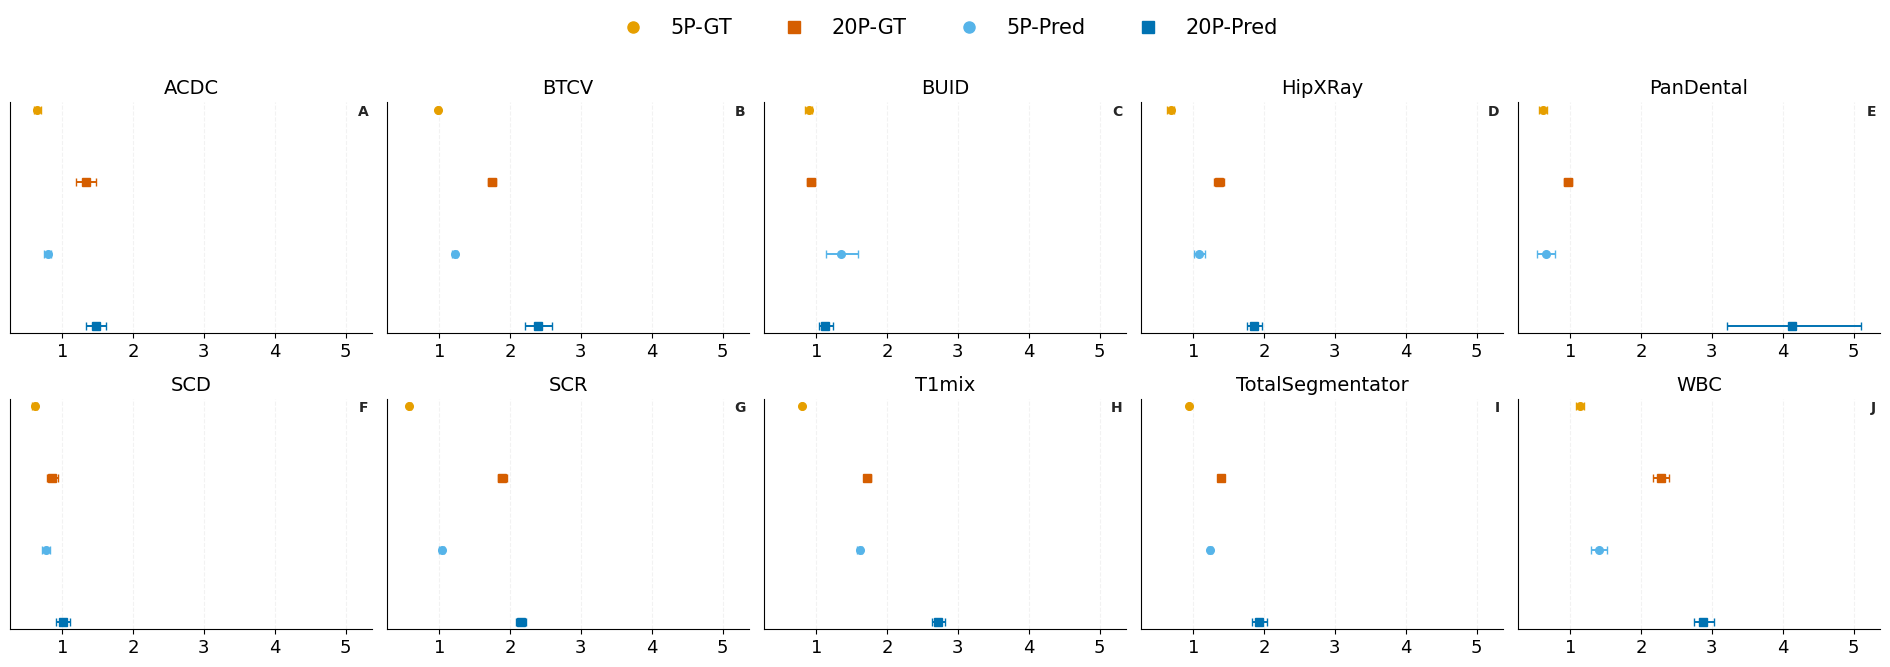

=== initial_dice ===


,family,ablation,metric,spread_mode,spread_label,mean,ci_lo,ci_hi,n_tasks,n_subsets
0,ACDC,pretrained_baseline,initial_dice,range,Range,0.152067,0.144098,0.160884,6,60
1,ACDC,pretrained_baseline5,initial_dice,range,Range,0.165007,0.156865,0.173652,6,60
2,ACDC,pretrained_baseline5_gt,initial_dice,range,Range,0.145366,0.137699,0.153007,6,60
3,ACDC,pretrained_baseline_gt,initial_dice,range,Range,0.145366,0.137699,0.153007,6,60
4,BTCV,pretrained_baseline,initial_dice,range,Range,0.180977,0.176166,0.186059,20,200
5,BTCV,pretrained_baseline5,initial_dice,range,Range,0.198452,0.192585,0.204530,20,200
6,BTCV,pretrained_baseline5_gt,initial_dice,range,Range,0.153882,0.149673,0.158166,20,200
7,BTCV,pretrained_baseline_gt,initial_dice,range,Range,0.153882,0.149673,0.158166,20,200
8,BUID,pretrained_baseline,initial_dice,range,Range,0.236297,0.223381,0.251096,4,40
9,BUID,pretrained_baseline5,initial_dice,range,Range,0.250965,0.231650,0.271558,4,40


saved: /data/ddmg/mvseg-ordering/paper/figures/random_v2_spread_hierci/initial_dice_range_forest_grid.pdf
saved: /data/ddmg/mvseg-ordering/paper/figures/random_v2_spread_hierci/initial_dice_range_forest_grid.png


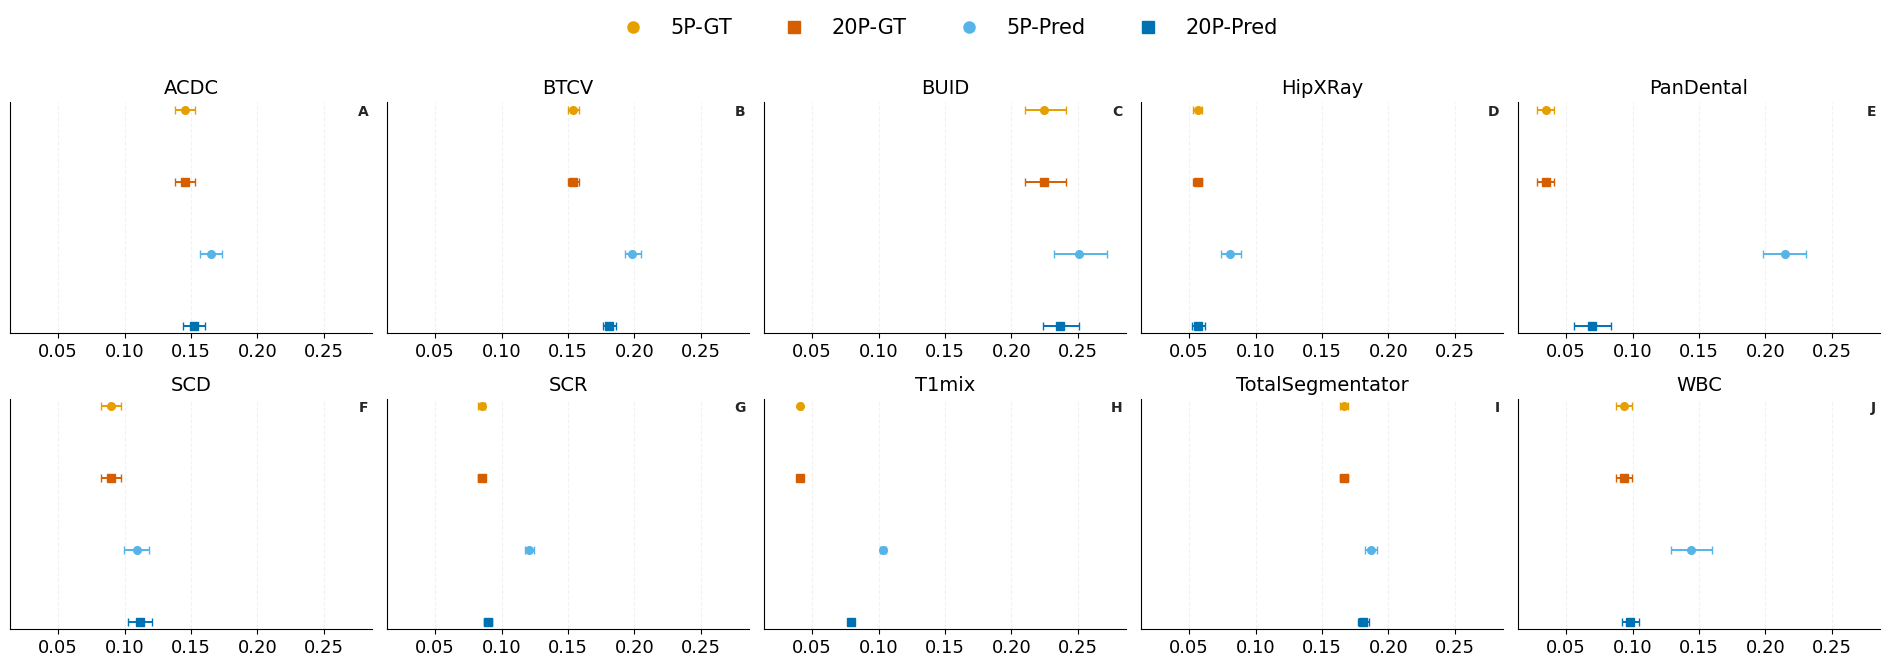

=== final_dice ===


,family,ablation,metric,spread_mode,spread_label,mean,ci_lo,ci_hi,n_tasks,n_subsets
0,ACDC,pretrained_baseline,final_dice,range,Range,0.018658,0.015554,0.022176,6,60
1,ACDC,pretrained_baseline5,final_dice,range,Range,0.050115,0.047080,0.053108,6,60
2,ACDC,pretrained_baseline5_gt,final_dice,range,Range,0.040761,0.037340,0.044501,6,60
3,ACDC,pretrained_baseline_gt,final_dice,range,Range,0.013851,0.011784,0.015846,6,60
4,BTCV,pretrained_baseline,final_dice,range,Range,0.028072,0.022671,0.034430,20,200
5,BTCV,pretrained_baseline5,final_dice,range,Range,0.099352,0.091133,0.108145,20,200
6,BTCV,pretrained_baseline5_gt,final_dice,range,Range,0.048042,0.046593,0.049527,20,200
7,BTCV,pretrained_baseline_gt,final_dice,range,Range,0.016747,0.015662,0.017956,20,200
8,BUID,pretrained_baseline,final_dice,range,Range,0.006138,0.005500,0.006908,4,40
9,BUID,pretrained_baseline5,final_dice,range,Range,0.087901,0.058745,0.123110,4,40


saved: /data/ddmg/mvseg-ordering/paper/figures/random_v2_spread_hierci/final_dice_range_forest_grid.pdf
saved: /data/ddmg/mvseg-ordering/paper/figures/random_v2_spread_hierci/final_dice_range_forest_grid.png


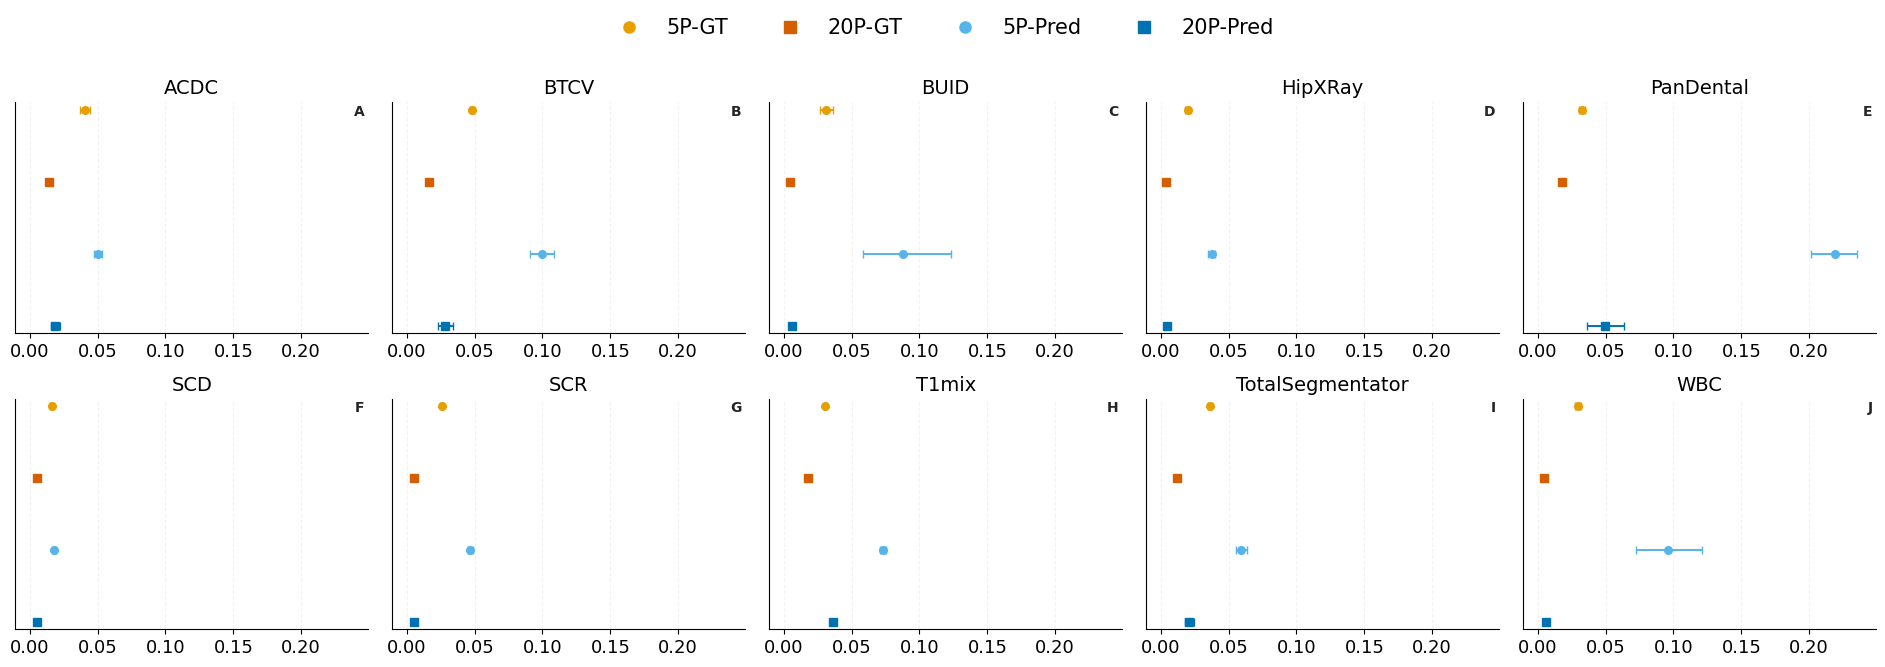

In [7]:
for metric in METRICS:
    print(f"=== {metric} ===")
    display(metric_to_summary.get(metric, pd.DataFrame()))
    plot_forest_grid_for_metric(metric, metric_to_summary.get(metric, pd.DataFrame()))


In [8]:
# Optional: save summary table for downstream analysis.
if not summary_all.empty:
    out_csv = REPO_ROOT / "paper" / "figures" / "random_v2_spread_hierci" / f"random_v2_spread_summary_{SPREAD_MODE}.csv"
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    summary_all.to_csv(out_csv, index=False)
    print(f"Wrote: {out_csv}")


Wrote: /data/ddmg/mvseg-ordering/paper/figures/random_v2_spread_hierci/random_v2_spread_summary_range.csv


In [9]:
def format_mean_ci_cell(row: pd.Series, digits: int = 4) -> str:
    return f"{row['mean']:.{digits}f} [{row['ci_lo']:.{digits}f}, {row['ci_hi']:.{digits}f}]"


metric_to_family_table: dict[str, pd.DataFrame] = {}

for metric, summary_df in metric_to_summary.items():
    if summary_df.empty:
        metric_to_family_table[metric] = pd.DataFrame()
        continue

    display_df = summary_df.copy()
    display_df["mean_95ci"] = display_df.apply(format_mean_ci_cell, axis=1)

    family_table = (
        display_df.pivot(
            index="ablation",
            columns="family",
            values="mean_95ci",
        )
        .reindex(ABLATIONS)
    )

    metric_to_family_table[metric] = family_table

ABLATION_LABELS = {
    "pretrained_baseline": "20P-Pred",
    "pretrained_baseline5": "5P-Pred",
    "pretrained_baseline_gt": "20P-GT",
    "pretrained_baseline5_gt": "5P-GT",
}

family_table = family_table.rename(index=ABLATION_LABELS)


for metric, family_table in metric_to_family_table.items():
    print(f"=== {metric} ({SPREAD_MODE}) ===")
    display(family_table)


=== iterations_used (range) ===


family,ACDC,BTCV,BUID,HipXRay,PanDental,SCD,SCR,T1mix,TotalSegmentator,WBC
ablation,,,,,,,,,,
pretrained_baseline,"1.4773 [1.3383, 1.6183]","2.3886 [2.2055, 2.5861]","1.1267 [1.0400, 1.2300]","1.8623 [1.7575, 1.9650]","4.1248 [3.2174, 5.1001]","1.0031 [0.9125, 1.1050]","2.1565 [2.0845, 2.2280]","2.7212 [2.6296, 2.8150]","1.9278 [1.8281, 2.0426]","2.8778 [2.7412, 3.0250]"
pretrained_baseline5,"0.7958 [0.7450, 0.8433]","1.2178 [1.1835, 1.2530]","1.3447 [1.1300, 1.5900]","1.0861 [1.0100, 1.1600]","0.6513 [0.5349, 0.7850]","0.7744 [0.7175, 0.8300]","1.0334 [1.0015, 1.0640]","1.6168 [1.5813, 1.6520]","1.2378 [1.2079, 1.2692]","1.3989 [1.2862, 1.5187]"
pretrained_baseline_gt,"1.3312 [1.1917, 1.4733]","1.7420 [1.6930, 1.7945]","0.9256 [0.8674, 0.9850]","1.3600 [1.2875, 1.4375]","0.9707 [0.9125, 1.0300]","0.8588 [0.7900, 0.9325]","1.8888 [1.8230, 1.9570]","1.7167 [1.6678, 1.7674]","1.3901 [1.3581, 1.4249]","2.2789 [2.1712, 2.3912]"
pretrained_baseline5_gt,"0.6473 [0.5967, 0.6967]","0.9859 [0.9635, 1.0090]","0.8908 [0.8425, 0.9450]","0.6801 [0.6300, 0.7275]","0.6095 [0.5575, 0.6675]","0.6107 [0.5774, 0.6450]","0.5776 [0.5560, 0.6010]","0.7991 [0.7804, 0.8174]","0.9376 [0.9198, 0.9547]","1.1347 [1.0813, 1.1888]"


=== initial_dice (range) ===


family,ACDC,BTCV,BUID,HipXRay,PanDental,SCD,SCR,T1mix,TotalSegmentator,WBC
ablation,,,,,,,,,,
pretrained_baseline,"0.1521 [0.1441, 0.1609]","0.1810 [0.1762, 0.1861]","0.2363 [0.2234, 0.2511]","0.0568 [0.0523, 0.0618]","0.0693 [0.0558, 0.0835]","0.1116 [0.1025, 0.1208]","0.0898 [0.0869, 0.0928]","0.0795 [0.0781, 0.0810]","0.1811 [0.1773, 0.1852]","0.0984 [0.0921, 0.1050]"
pretrained_baseline5,"0.1650 [0.1569, 0.1737]","0.1985 [0.1926, 0.2045]","0.2510 [0.2317, 0.2716]","0.0810 [0.0739, 0.0887]","0.2149 [0.1979, 0.2306]","0.1090 [0.0998, 0.1185]","0.1210 [0.1174, 0.1247]","0.1035 [0.1014, 0.1057]","0.1868 [0.1826, 0.1914]","0.1440 [0.1290, 0.1595]"
pretrained_baseline_gt,"0.1454 [0.1377, 0.1530]","0.1539 [0.1497, 0.1582]","0.2245 [0.2102, 0.2412]","0.0564 [0.0528, 0.0599]","0.0345 [0.0284, 0.0409]","0.0898 [0.0826, 0.0970]","0.0852 [0.0825, 0.0878]","0.0412 [0.0398, 0.0426]","0.1665 [0.1633, 0.1695]","0.0933 [0.0874, 0.0994]"
pretrained_baseline5_gt,"0.1454 [0.1377, 0.1530]","0.1539 [0.1497, 0.1582]","0.2245 [0.2102, 0.2412]","0.0564 [0.0528, 0.0599]","0.0345 [0.0284, 0.0409]","0.0898 [0.0826, 0.0970]","0.0852 [0.0825, 0.0878]","0.0412 [0.0398, 0.0426]","0.1665 [0.1633, 0.1695]","0.0933 [0.0874, 0.0994]"


=== final_dice (range) ===


family,ACDC,BTCV,BUID,HipXRay,PanDental,SCD,SCR,T1mix,TotalSegmentator,WBC
ablation,,,,,,,,,,
pretrained_baseline,"0.0187 [0.0156, 0.0222]","0.0281 [0.0227, 0.0344]","0.0061 [0.0055, 0.0069]","0.0044 [0.0042, 0.0046]","0.0493 [0.0360, 0.0637]","0.0056 [0.0053, 0.0059]","0.0056 [0.0055, 0.0058]","0.0360 [0.0344, 0.0377]","0.0207 [0.0175, 0.0245]","0.0062 [0.0057, 0.0068]"
pretrained_baseline5,"0.0501 [0.0471, 0.0531]","0.0994 [0.0911, 0.1081]","0.0879 [0.0587, 0.1231]","0.0376 [0.0352, 0.0402]","0.2193 [0.2013, 0.2353]","0.0182 [0.0170, 0.0196]","0.0468 [0.0449, 0.0489]","0.0730 [0.0710, 0.0750]","0.0594 [0.0556, 0.0638]","0.0960 [0.0723, 0.1209]"
pretrained_baseline_gt,"0.0139 [0.0118, 0.0158]","0.0167 [0.0157, 0.0180]","0.0046 [0.0043, 0.0049]","0.0036 [0.0034, 0.0038]","0.0177 [0.0162, 0.0192]","0.0053 [0.0049, 0.0057]","0.0051 [0.0049, 0.0053]","0.0178 [0.0173, 0.0182]","0.0116 [0.0109, 0.0125]","0.0047 [0.0043, 0.0051]"
pretrained_baseline5_gt,"0.0408 [0.0373, 0.0445]","0.0480 [0.0466, 0.0495]","0.0312 [0.0266, 0.0362]","0.0199 [0.0180, 0.0218]","0.0327 [0.0305, 0.0352]","0.0162 [0.0152, 0.0172]","0.0259 [0.0250, 0.0269]","0.0304 [0.0298, 0.0310]","0.0362 [0.0351, 0.0374]","0.0298 [0.0273, 0.0322]"


In [10]:
from pathlib import Path
import numpy as np
import pandas as pd

from experiments.analysis.planb_utils import load_planb_summaries
from experiments.analysis.hierarchical_ci import hierarchical_bootstrap_global_dataset_stat

REPO_ROOT = Path("/data/ddmg/mvseg-ordering")


def _spread_reducer(mode: str):
    mode = mode.lower().strip()
    if mode == "iqr":
        return lambda x: float(np.quantile(x, 0.75) - np.quantile(x, 0.25))
    if mode == "range":
        return lambda x: float(np.max(x) - np.min(x))
    raise ValueError("mode must be 'iqr' or 'range'")


def global_stat_per_ablation(
    *,
    procedure: str,
    ablations: list[str],
    metrics: list[str],
    spread_modes: list[str],
    policy_name: str = "random",
    n_boot: int = 2000,
    seed: int = 23,
) -> pd.DataFrame:
    """Compute one global hierarchical-bootstrap stat per ablation/metric/spread mode."""
    rows: list[dict[str, object]] = []

    # Load once per ablation (faster and cleaner than re-loading for every metric/mode).
    data_by_ablation: dict[str, pd.DataFrame] = {}
    for ablation in ablations:
        df = load_planb_summaries(
            repo_root=REPO_ROOT,
            procedure=procedure,
            ablation=ablation,
            dataset=None,
            filename="subset_support_images_summary.csv",
            allow_root_fallback=True,
        )
        df = df[df["policy_name"].astype(str) == policy_name].copy()
        if not df.empty:
            data_by_ablation[ablation] = df

    for spread_mode in spread_modes:
        reducer = _spread_reducer(spread_mode)
        for metric in metrics:
            for ablation in ablations:
                df = data_by_ablation.get(ablation)
                if df is None or metric not in df.columns:
                    continue

                stats = hierarchical_bootstrap_global_dataset_stat(
                    df,
                    metric=metric,
                    policy_name=policy_name,
                    reducer=reducer,
                    stat_name="subset_spread",
                    n_boot=n_boot,
                    seed=seed,
                    dataset_col="family",
                    task_col="task_id",
                    policy_col="policy_name",
                )

                rows.append(
                    {
                        "ablation": ablation,
                        "metric": metric,
                        "policy_name": policy_name,
                        "spread_mode": spread_mode,
                        "global_mean": stats["mean"],
                        "global_ci_lo": stats["ci_lo"],
                        "global_ci_hi": stats["ci_hi"],
                    }
                )

    out = pd.DataFrame(rows)
    if out.empty:
        return out
    return out.sort_values(["spread_mode", "metric", "ablation"]).reset_index(drop=True)


ABLATIONS = [
    "pretrained_baseline",
    "pretrained_baseline5",
    "pretrained_baseline_gt",
    "pretrained_baseline5_gt",
]

GLOBAL_STATS = global_stat_per_ablation(
    procedure="random_v2",
    ablations=ABLATIONS,
    metrics=["initial_dice", "final_dice", "iterations_used"],
    spread_modes=["iqr", "range"],
    policy_name="random",
    n_boot=2000,
    seed=23,
)

display(GLOBAL_STATS)

# Optional compact trend table (means only)
if not GLOBAL_STATS.empty:
    display(
        GLOBAL_STATS.pivot_table(
            index="ablation",
            columns=["spread_mode", "metric"],
            values="global_mean",
            aggfunc="first",
        )
    )


,ablation,metric,policy_name,spread_mode,global_mean,global_ci_lo,global_ci_hi
0,pretrained_baseline,final_dice,random,iqr,0.003352,0.003255,0.003460
1,pretrained_baseline5,final_dice,random,iqr,0.014208,0.013816,0.014629
2,pretrained_baseline5_gt,final_dice,random,iqr,0.007575,0.007451,0.007706
3,pretrained_baseline_gt,final_dice,random,iqr,0.002435,0.002349,0.002528
4,pretrained_baseline,initial_dice,random,iqr,0.032778,0.031943,0.033587
5,pretrained_baseline5,initial_dice,random,iqr,0.039540,0.038859,0.040280
6,pretrained_baseline5_gt,initial_dice,random,iqr,0.029745,0.028865,0.030661
7,pretrained_baseline_gt,initial_dice,random,iqr,0.029745,0.028865,0.030661
8,pretrained_baseline,iterations_used,random,iqr,0.510309,0.500068,0.520763
9,pretrained_baseline5,iterations_used,random,iqr,0.293601,0.285991,0.301208


spread_mode                    iqr                                   range  \
metric                  final_dice initial_dice iterations_used final_dice   
ablation                                                                     
pretrained_baseline       0.003352     0.032778        0.510309   0.018074   
pretrained_baseline5      0.014208     0.039540        0.293601   0.078770   
pretrained_baseline5_gt   0.007575     0.029745        0.216108   0.031112   
pretrained_baseline_gt    0.002435     0.029745        0.388071   0.010086   

spread_mode                                           
metric                  initial_dice iterations_used  
ablation                                              
pretrained_baseline         0.125598        2.166606  
pretrained_baseline5        0.157461        1.115704  
pretrained_baseline5_gt     0.109051        0.787345  
pretrained_baseline_gt      0.109051        1.446290

In [11]:
from experiments.analysis.planb_utils import load_planb_summaries
from experiments.analysis.hierarchical_ci import (
    compute_subset_stat,
    hierarchical_bootstrap_global_stats,
)

PAIR_KEYS = ["family", "task_id", "subset_index"]

# Choose which contrast to compute:
# - budget_within_regime: (5P - 20P) within Pred and within GT
# - commit_within_budget: (Pred - GT) within 20P and within 5P
PAIR_MAPS = {
    "budget_within_regime": {
        "Pred: 5P-20P": ("pretrained_baseline5", "pretrained_baseline"),
        "GT: 5P-20P": ("pretrained_baseline5_gt", "pretrained_baseline_gt"),
    },
    "commit_within_budget": {
        "20P: Pred-GT": ("pretrained_baseline", "pretrained_baseline_gt"),
        "5P: Pred-GT": ("pretrained_baseline5", "pretrained_baseline5_gt"),
    },
}

COMPARISON_MODE = "budget_within_regime"
COMPARE_LABEL = {
    "budget_within_regime": "delta_left_minus_right (5P - 20P)",
    "commit_within_budget": "delta_left_minus_right (Pred - GT)",
}[COMPARISON_MODE]


def global_pair_delta_stats(
    *,
    procedure: str,
    pair_map: dict[str, tuple[str, str]],
    metrics: list[str],
    spread_modes: list[str],
    policy_name: str = "random",
    n_boot: int = 2000,
    seed: int = 23,
) -> pd.DataFrame:
    rows: list[dict[str, object]] = []

    needed_ablations = sorted({ab for left_right in pair_map.values() for ab in left_right})
    raw_by_ablation: dict[str, pd.DataFrame] = {}

    for ablation in needed_ablations:
        df = load_planb_summaries(
            repo_root=REPO_ROOT,
            procedure=procedure,
            ablation=ablation,
            dataset=None,
            filename="subset_support_images_summary.csv",
            allow_root_fallback=True,
        )
        df = df[df["policy_name"].astype(str) == policy_name].copy()
        if not df.empty:
            raw_by_ablation[ablation] = df

    for spread_mode in spread_modes:
        reducer = _spread_reducer(spread_mode)

        for metric in metrics:
            subset_by_ablation: dict[str, pd.DataFrame] = {}
            for ablation, df in raw_by_ablation.items():
                if metric not in df.columns:
                    continue
                subset_by_ablation[ablation] = compute_subset_stat(
                    df,
                    metric,
                    reducer=reducer,
                    stat_name="subset_spread",
                    task_col="task_id",
                    policy_col="policy_name",
                    extra_group_cols=["family"],
                )

            for contrast_name, (left_ab, right_ab) in pair_map.items():
                left = subset_by_ablation.get(left_ab)
                right = subset_by_ablation.get(right_ab)
                if left is None or right is None:
                    continue

                left = left[PAIR_KEYS + ["subset_spread"]].rename(columns={"subset_spread": "left_spread"})
                right = right[PAIR_KEYS + ["subset_spread"]].rename(columns={"subset_spread": "right_spread"})
                paired = left.merge(right, on=PAIR_KEYS, how="inner", validate="one_to_one")
                if paired.empty:
                    continue

                paired["delta"] = paired["left_spread"] - paired["right_spread"]

                stats = hierarchical_bootstrap_global_stats(
                    paired[["family", "task_id", "delta"]],
                    value_col="delta",
                    dataset_col="family",
                    task_col="task_id",
                    n_boot=n_boot,
                    seed=seed,
                )

                boot = stats["global_bootstrap"]
                p_delta_gt_0 = float((boot > 0).mean()) if len(boot) else np.nan

                rows.append(
                    {
                        "comparison_mode": COMPARISON_MODE,
                        "contrast": contrast_name,
                        "spread_mode": spread_mode,
                        "metric": metric,
                        "delta_mean_left_minus_right": stats["mean"],
                        "delta_ci_lo": stats["ci_lo"],
                        "delta_ci_hi": stats["ci_hi"],
                        "p_delta_gt_0": p_delta_gt_0,
                        "n_pairs": int(len(paired)),
                        "n_tasks": int(paired["task_id"].nunique()),
                        "n_datasets": int(paired["family"].nunique()),
                    }
                )

    out = pd.DataFrame(rows)
    if out.empty:
        return out
    return out.sort_values(["spread_mode", "metric", "contrast"]).reset_index(drop=True)


GLOBAL_PAIR_DELTAS = global_pair_delta_stats(
    procedure="random_v2",
    pair_map=PAIR_MAPS[COMPARISON_MODE],
    metrics=["initial_dice", "final_dice", "iterations_used"],
    spread_modes=["iqr", "range"],
    policy_name="random",
    n_boot=2000,
    seed=23,
)

print(COMPARE_LABEL)
display(GLOBAL_PAIR_DELTAS)

if not GLOBAL_PAIR_DELTAS.empty:
    display(
        GLOBAL_PAIR_DELTAS.pivot_table(
            index=["spread_mode", "metric"],
            columns="contrast",
            values="delta_mean_left_minus_right",
            aggfunc="first",
        )
    )


delta_left_minus_right (5P - 20P)


,comparison_mode,contrast,spread_mode,metric,delta_mean_left_minus_right,delta_ci_lo,delta_ci_hi,p_delta_gt_0,n_pairs,n_tasks,n_datasets
0,budget_within_regime,GT: 5P-20P,iqr,final_dice,0.005140,0.005016,0.005260,1.0,1630,163,10
1,budget_within_regime,Pred: 5P-20P,iqr,final_dice,0.010856,0.010448,0.011279,1.0,1630,163,10
2,budget_within_regime,GT: 5P-20P,iqr,initial_dice,0.000000,0.000000,0.000000,0.0,1630,163,10
3,budget_within_regime,Pred: 5P-20P,iqr,initial_dice,0.006762,0.006341,0.007209,1.0,1630,163,10
4,budget_within_regime,GT: 5P-20P,iqr,iterations_used,-0.171964,-0.180239,-0.164313,0.0,1630,163,10
5,budget_within_regime,Pred: 5P-20P,iqr,iterations_used,-0.216709,-0.230195,-0.203623,0.0,1630,163,10
6,budget_within_regime,GT: 5P-20P,range,final_dice,0.021025,0.020358,0.021739,1.0,1630,163,10
7,budget_within_regime,Pred: 5P-20P,range,final_dice,0.060696,0.056210,0.065501,1.0,1630,163,10
8,budget_within_regime,GT: 5P-20P,range,initial_dice,0.000000,0.000000,0.000000,0.0,1630,163,10
9,budget_within_regime,Pred: 5P-20P,range,initial_dice,0.031863,0.029241,0.034632,1.0,1630,163,10


contrast                     GT: 5P-20P  Pred: 5P-20P
spread_mode metric                                   
iqr         final_dice         0.005140      0.010856
            initial_dice       0.000000      0.006762
            iterations_used   -0.171964     -0.216709
range       final_dice         0.021025      0.060696
            initial_dice       0.000000      0.031863
            iterations_used   -0.658945     -1.050903

In [13]:
from experiments.analysis.planb_utils import load_planb_summaries
from experiments.analysis.hierarchical_ci import (
    compute_subset_stat,
    hierarchical_bootstrap_global_stats,
)

PAIR_KEYS = ["family", "task_id", "subset_index"]

# Choose which contrast to compute:
# - budget_within_regime: (5P - 20P) within Pred and within GT
# - commit_within_budget: (Pred - GT) within 20P and within 5P
PAIR_MAPS = {
    "budget_within_regime": {
        "Pred: 5P-20P": ("pretrained_baseline5", "pretrained_baseline"),
        "GT: 5P-20P": ("pretrained_baseline5_gt", "pretrained_baseline_gt"),
    },
    "commit_within_budget": {
        "20P: Pred-GT": ("pretrained_baseline", "pretrained_baseline_gt"),
        "5P: Pred-GT": ("pretrained_baseline5", "pretrained_baseline5_gt"),
    },
}

COMPARISON_MODE = "commit_within_budget"
COMPARE_LABEL = {
    "budget_within_regime": "delta_left_minus_right (5P - 20P)",
    "commit_within_budget": "delta_left_minus_right (Pred - GT)",
}[COMPARISON_MODE]


def global_pair_delta_stats(
    *,
    procedure: str,
    pair_map: dict[str, tuple[str, str]],
    metrics: list[str],
    spread_modes: list[str],
    policy_name: str = "random",
    n_boot: int = 2000,
    seed: int = 23,
) -> pd.DataFrame:
    rows: list[dict[str, object]] = []

    needed_ablations = sorted({ab for left_right in pair_map.values() for ab in left_right})
    raw_by_ablation: dict[str, pd.DataFrame] = {}

    for ablation in needed_ablations:
        df = load_planb_summaries(
            repo_root=REPO_ROOT,
            procedure=procedure,
            ablation=ablation,
            dataset=None,
            filename="subset_support_images_summary.csv",
            allow_root_fallback=True,
        )
        df = df[df["policy_name"].astype(str) == policy_name].copy()
        if not df.empty:
            raw_by_ablation[ablation] = df

    for spread_mode in spread_modes:
        reducer = _spread_reducer(spread_mode)

        for metric in metrics:
            subset_by_ablation: dict[str, pd.DataFrame] = {}
            for ablation, df in raw_by_ablation.items():
                if metric not in df.columns:
                    continue
                subset_by_ablation[ablation] = compute_subset_stat(
                    df,
                    metric,
                    reducer=reducer,
                    stat_name="subset_spread",
                    task_col="task_id",
                    policy_col="policy_name",
                    extra_group_cols=["family"],
                )

            for contrast_name, (left_ab, right_ab) in pair_map.items():
                left = subset_by_ablation.get(left_ab)
                right = subset_by_ablation.get(right_ab)
                if left is None or right is None:
                    continue

                left = left[PAIR_KEYS + ["subset_spread"]].rename(columns={"subset_spread": "left_spread"})
                right = right[PAIR_KEYS + ["subset_spread"]].rename(columns={"subset_spread": "right_spread"})
                paired = left.merge(right, on=PAIR_KEYS, how="inner", validate="one_to_one")
                if paired.empty:
                    continue

                paired["delta"] = paired["left_spread"] - paired["right_spread"]

                stats = hierarchical_bootstrap_global_stats(
                    paired[["family", "task_id", "delta"]],
                    value_col="delta",
                    dataset_col="family",
                    task_col="task_id",
                    n_boot=n_boot,
                    seed=seed,
                )

                boot = stats["global_bootstrap"]
                p_delta_gt_0 = float((boot > 0).mean()) if len(boot) else np.nan

                rows.append(
                    {
                        "comparison_mode": COMPARISON_MODE,
                        "contrast": contrast_name,
                        "spread_mode": spread_mode,
                        "metric": metric,
                        "delta_mean_left_minus_right": stats["mean"],
                        "delta_ci_lo": stats["ci_lo"],
                        "delta_ci_hi": stats["ci_hi"],
                        "p_delta_gt_0": p_delta_gt_0,
                        "n_pairs": int(len(paired)),
                        "n_tasks": int(paired["task_id"].nunique()),
                        "n_datasets": int(paired["family"].nunique()),
                    }
                )

    out = pd.DataFrame(rows)
    if out.empty:
        return out
    return out.sort_values(["spread_mode", "metric", "contrast"]).reset_index(drop=True)


GLOBAL_PAIR_DELTAS = global_pair_delta_stats(
    procedure="random_v2",
    pair_map=PAIR_MAPS[COMPARISON_MODE],
    metrics=["initial_dice", "final_dice", "iterations_used"],
    spread_modes=["iqr", "range"],
    policy_name="random",
    n_boot=2000,
    seed=23,
)

print(COMPARE_LABEL)
display(GLOBAL_PAIR_DELTAS)

if not GLOBAL_PAIR_DELTAS.empty:
    display(
        GLOBAL_PAIR_DELTAS.pivot_table(
            index=["spread_mode", "metric"],
            columns="contrast",
            values="delta_mean_left_minus_right",
            aggfunc="first",
        )
    )


delta_left_minus_right (Pred - GT)


,comparison_mode,contrast,spread_mode,metric,delta_mean_left_minus_right,delta_ci_lo,delta_ci_hi,p_delta_gt_0,n_pairs,n_tasks,n_datasets
0,commit_within_budget,20P: Pred-GT,iqr,final_dice,0.000918,0.000820,0.001010,1.0,1630,163,10
1,commit_within_budget,5P: Pred-GT,iqr,final_dice,0.006633,0.006253,0.007039,1.0,1630,163,10
2,commit_within_budget,20P: Pred-GT,iqr,initial_dice,0.003033,0.002558,0.003530,1.0,1630,163,10
3,commit_within_budget,5P: Pred-GT,iqr,initial_dice,0.009795,0.009226,0.010362,1.0,1630,163,10
4,commit_within_budget,20P: Pred-GT,iqr,iterations_used,0.122238,0.113259,0.131239,1.0,1630,163,10
5,commit_within_budget,5P: Pred-GT,iqr,iterations_used,0.077493,0.069259,0.085517,1.0,1630,163,10
6,commit_within_budget,20P: Pred-GT,range,final_dice,0.007988,0.006468,0.009646,1.0,1630,163,10
7,commit_within_budget,5P: Pred-GT,range,final_dice,0.047658,0.043427,0.052179,1.0,1630,163,10
8,commit_within_budget,20P: Pred-GT,range,initial_dice,0.016547,0.014622,0.018462,1.0,1630,163,10
9,commit_within_budget,5P: Pred-GT,range,initial_dice,0.048410,0.045768,0.051144,1.0,1630,163,10


contrast                     20P: Pred-GT  5P: Pred-GT
spread_mode metric                                    
iqr         final_dice           0.000918     0.006633
            initial_dice         0.003033     0.009795
            iterations_used      0.122238     0.077493
range       final_dice           0.007988     0.047658
            initial_dice         0.016547     0.048410
            iterations_used      0.720317     0.328359